# 06 — Multi-Tournament Pipeline

**Goal:** Extend the 2022 passing-network analysis to include 2018, building a two-tournament dataset of group-stage team profiles for historical comparison and eventual modelling.

**Data source:** StatsBomb Open Data (competition_id = 43)
- 2018 World Cup — season_id = 3
- 2022 World Cup — season_id = 106
- 2014 World Cup — **not available** in StatsBomb open data

**Key outputs:**
- `data/processed/2018_group_stage_team_profiles.csv`
- `data/processed/2022_group_stage_team_profiles.csv`
- `data/processed/worldcup_group_stage_team_profiles.csv` (combined)
- `outputs/tables/multi_tournament_qf_comparison.csv`
- `outputs/tables/qf_comparison_by_tournament.csv`

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')   # suppress StatsBomb auth warnings

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb

from pipeline import (
    load_tournament_matches,
    build_match_features,
    aggregate_group_stage_profiles,
    get_qf_teams,
)

DATA_DIR  = Path('../data')
RAW_DIR   = DATA_DIR / 'raw'
PROC_DIR  = DATA_DIR / 'processed'
TABLE_DIR = Path('../outputs/tables')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Available World Cup seasons in StatsBomb open data

In [2]:
comps = sb.competitions()
wc    = comps[comps['competition_name'].str.contains('FIFA World Cup', na=False)].copy()
wc    = wc[['competition_id', 'season_id', 'competition_name', 'season_name']]
wc    = wc.sort_values('season_name').reset_index(drop=True)

print('Available FIFA World Cup data in StatsBomb open data:')
print(wc.to_string(index=False))
print()
print('NOTE: 2014 is not available. This pipeline uses 2018 and 2022.')
print('NOTE: 1958-1990 seasons are available as match metadata only (no event-level data).')

Available FIFA World Cup data in StatsBomb open data:
 competition_id  season_id competition_name season_name
             43        269   FIFA World Cup        1958
             43        270   FIFA World Cup        1962
             43        272   FIFA World Cup        1970
             43         51   FIFA World Cup        1974
             43         54   FIFA World Cup        1986
             43         55   FIFA World Cup        1990
             43          3   FIFA World Cup        2018
             43        106   FIFA World Cup        2022

NOTE: 2014 is not available. This pipeline uses 2018 and 2022.
NOTE: 1958-1990 seasons are available as match metadata only (no event-level data).


## 2. Process 2022 World Cup

Reuse the already-computed `team_match_network_features_normalized.csv` from notebooks 03–05 — no re-downloading needed.

In [3]:
# Load 2022 match metadata
matches_2022 = load_tournament_matches(
    competition_id=43, season_id=106,
    cache_path=RAW_DIR / 'matches.csv',
)

# Load already-computed 2022 match-level features (from notebook 03)
mf_2022 = pd.read_csv(PROC_DIR / 'team_match_network_features_normalized.csv')
mf_2022['tournament_year'] = 2022

print(f'2022 match features loaded: {mf_2022.shape}')
print(f'Stages: {mf_2022["stage"].value_counts().to_dict()}')

# Aggregate to one row per team (group stage only)
profiles_2022 = aggregate_group_stage_profiles(mf_2022, matches_2022, 2022)

print(f'\n2022 team profiles: {profiles_2022.shape}')
print(f'QF teams: {sorted(profiles_2022[profiles_2022["reached_qf"]==1]["team"].tolist())}')
profiles_2022[['team', 'stage_reached', 'reached_qf',
               'avg_completed_passes', 'avg_network_density',
               'avg_final_third_entries_per_100_passes']].head(8)

2022 match features loaded: (128, 26)
Stages: {'group': 96, 'R16': 16, 'QF': 8, 'SF': 4, 'Final': 2, '3rd Place Final': 2}

2022 team profiles: (32, 18)
QF teams: ['Argentina', 'Brazil', 'Croatia', 'England', 'France', 'Morocco', 'Netherlands', 'Portugal']


,team,stage_reached,reached_qf,avg_completed_passes,avg_network_density,avg_final_third_entries_per_100_passes
0,Argentina,Final,1,614.667,0.615,7.070
1,Australia,Round of 16,0,295.667,0.449,8.653
2,Belgium,Group Stage,0,532.667,0.556,5.393
3,Brazil,Quarter-final,1,519.333,0.553,7.997
4,Cameroon,Group Stage,0,323.333,0.518,9.000
5,Canada,Group Stage,0,439.333,0.575,9.680
6,Costa Rica,Group Stage,0,276.667,0.480,4.730
7,Croatia,3rd Place,1,500.667,0.548,6.463


## 3. Process 2018 World Cup

First run downloads all 64 match event files (~5–8 minutes). Subsequent runs read from local parquet cache and finish in seconds.

In [4]:
matches_2018 = load_tournament_matches(
    competition_id=43, season_id=3,
    cache_path=RAW_DIR / '2018' / 'matches.csv',
)

print(f'2018 matches: {len(matches_2018)}')
print(f'Stages: {matches_2018["stage_label"].value_counts().to_dict()}')
print(f'QF teams: {sorted(get_qf_teams(matches_2018))}')

2018 matches: 64
Stages: {'group': 48, 'R16': 8, 'QF': 4, 'SF': 2, 'Final': 1, '3rd': 1}
QF teams: ['Belgium', 'Brazil', 'Croatia', 'England', 'France', 'Russia', 'Sweden', 'Uruguay']


In [5]:
# Build match-level features for 2018
# First run downloads events from StatsBomb (may take a few minutes).
# All files are cached in data/raw/2018/events/ for subsequent runs.

mf_2018 = build_match_features(
    matches_2018,
    events_cache_dir=RAW_DIR / '2018' / 'events',
    tournament_year=2018,
    verbose=True,
)

print(f'\n2018 match features: {mf_2018.shape}')
mf_2018.to_csv(PROC_DIR / '2018_match_features.csv', index=False)
print('Saved: data/processed/2018_match_features.csv')

  [01/64] Brazil vs Belgium  [QF]  (cache)
  [02/64] Belgium vs Japan  [R16]  (cache)
  [03/64] England vs Panama  [group]  (cache)
  [04/64] Poland vs Senegal  [group]  (cache)
  [05/64] Serbia vs Switzerland  [group]  (cache)
  [06/64] Sweden vs South Korea  [group]  (cache)
  [07/64] Germany vs Mexico  [group]  (cache)
  [08/64] Iran vs Spain  [group]  (cache)
  [09/64] Uruguay vs Saudi Arabia  [group]  (cache)
  [10/64] France vs Peru  [group]  (cache)
  [11/64] Argentina vs Croatia  [group]  (cache)
  [12/64] Colombia vs England  [R16]  (cache)
  [13/64] Panama vs Tunisia  [group]  (cache)
  [14/64] Japan vs Poland  [group]  (cache)
  [15/64] Iceland vs Croatia  [group]  (cache)
  [16/64] Russia vs Egypt  [group]  (cache)
  [17/64] Argentina vs Iceland  [group]  (cache)
  [18/64] England vs Belgium  [group]  (cache)
  [19/64] Sweden vs Switzerland  [R16]  (cache)
  [20/64] Iran vs Portugal  [group]  (cache)
  [21/64] Portugal vs Morocco  [group]  (cache)
  [22/64] Croatia vs Engla

In [6]:
# Aggregate to one row per team (group stage only)
profiles_2018 = aggregate_group_stage_profiles(mf_2018, matches_2018, 2018)

print(f'2018 team profiles: {profiles_2018.shape}')
print(f'QF teams: {sorted(profiles_2018[profiles_2018["reached_qf"]==1]["team"].tolist())}')
profiles_2018[['team', 'stage_reached', 'reached_qf',
               'avg_completed_passes', 'avg_network_density',
               'avg_final_third_entries_per_100_passes']].head(8)

2018 team profiles: (32, 18)
QF teams: ['Belgium', 'Brazil', 'Croatia', 'England', 'France', 'Russia', 'Sweden', 'Uruguay']


,team,stage_reached,reached_qf,avg_completed_passes,avg_network_density,avg_final_third_entries_per_100_passes
0,Argentina,Round of 16,0,528.667,0.662,8.410
1,Australia,Group Stage,0,424.333,0.559,7.293
2,Belgium,3rd Place,1,464.000,0.619,7.183
3,Brazil,Quarter-final,1,562.333,0.672,7.883
4,Colombia,Round of 16,0,366.333,0.622,9.103
5,Costa Rica,Group Stage,0,287.000,0.549,8.237
6,Croatia,Final,1,371.333,0.548,8.250
7,Denmark,Round of 16,0,311.333,0.587,9.357


## 4. Combine and save all outputs

In [7]:
# Save tournament-specific files
profiles_2018.to_csv(PROC_DIR / '2018_group_stage_team_profiles.csv', index=False)
profiles_2022.to_csv(PROC_DIR / '2022_group_stage_team_profiles.csv', index=False)

# Combine into multi-tournament dataset
combined = pd.concat([profiles_2018, profiles_2022], ignore_index=True)
combined.to_csv(PROC_DIR / 'worldcup_group_stage_team_profiles.csv', index=False)

print('Saved:')
print('  data/processed/2018_group_stage_team_profiles.csv')
print('  data/processed/2022_group_stage_team_profiles.csv')
print('  data/processed/worldcup_group_stage_team_profiles.csv')
print()
print(f'Combined shape: {combined.shape}  ({len(combined)} teams across 2 tournaments)')
print(f'Reached QF = 1: {combined["reached_qf"].sum()} rows')
print(f'Reached QF = 0: {(combined["reached_qf"]==0).sum()} rows')

Saved:
  data/processed/2018_group_stage_team_profiles.csv
  data/processed/2022_group_stage_team_profiles.csv
  data/processed/worldcup_group_stage_team_profiles.csv

Combined shape: (64, 18)  (64 teams across 2 tournaments)
Reached QF = 1: 16 rows
Reached QF = 0: 48 rows


## 5. QF+ vs non-QF: across all tournaments (combined)

In [8]:
COMPARE_COLS = [
    'avg_completed_passes',
    'avg_network_density',
    'avg_final_third_entries',
    'avg_final_third_entries_per_100_passes',
    'avg_connections_per_100_passes',
    'avg_passes_per_connection',
    'avg_top_player_reliance',
]

rows = []
for col in COMPARE_COLS:
    qm  = combined[combined['reached_qf']==1][col].mean()
    nm  = combined[combined['reached_qf']==0][col].mean()
    qmd = combined[combined['reached_qf']==1][col].median()
    nmd = combined[combined['reached_qf']==0][col].median()
    pct = (qm - nm) / nm * 100 if nm else np.nan
    rows.append({'metric': col,
                 'qf_mean': round(qm,3), 'non_qf_mean': round(nm,3),
                 'mean_diff_pct': round(pct,1),
                 'qf_median': round(qmd,3), 'non_qf_median': round(nmd,3)})

overall_comparison = pd.DataFrame(rows)
overall_comparison.to_csv(TABLE_DIR / 'multi_tournament_qf_comparison.csv', index=False)

print('QF+ vs non-QF — combined 2018 + 2022 group stage (64 teams total)\n')
overall_comparison

QF+ vs non-QF — combined 2018 + 2022 group stage (64 teams total)



,metric,qf_mean,non_qf_mean,mean_diff_pct,qf_median,non_qf_median
0,avg_completed_passes,469.146,384.049,22.2,495.000,367.833
1,avg_network_density,0.586,0.560,4.6,0.593,0.558
2,avg_final_third_entries,37.021,31.264,18.4,40.000,30.333
3,avg_final_third_entries_per_100_passes,7.947,8.236,-3.5,7.870,8.245
4,avg_connections_per_100_passes,26.388,31.391,-15.9,23.916,31.413
5,avg_passes_per_connection,3.993,3.472,15.0,4.258,3.244
6,avg_top_player_reliance,0.146,0.149,-1.5,0.147,0.146


## 6. QF+ vs non-QF: by tournament year

Check whether the pattern is consistent across both tournaments.

In [9]:
by_tournament_rows = []
for year in [2018, 2022]:
    sub = combined[combined['tournament_year'] == year]
    for col in COMPARE_COLS:
        qm  = sub[sub['reached_qf']==1][col].mean()
        nm  = sub[sub['reached_qf']==0][col].mean()
        pct = (qm - nm) / nm * 100 if nm else np.nan
        by_tournament_rows.append({
            'tournament_year': year,
            'metric': col,
            'qf_mean': round(qm, 3),
            'non_qf_mean': round(nm, 3),
            'mean_diff_pct': round(pct, 1),
        })

by_tournament = pd.DataFrame(by_tournament_rows)
by_tournament.to_csv(TABLE_DIR / 'qf_comparison_by_tournament.csv', index=False)

# Pivot for easier reading
pivot = by_tournament.pivot(index='metric', columns='tournament_year',
                             values='mean_diff_pct')
pivot.columns = [f'diff_pct_{y}' for y in pivot.columns]

print('% difference QF+ vs non-QF (positive = QF+ higher):')
print(pivot.to_string())

% difference QF+ vs non-QF (positive = QF+ higher):
                                        diff_pct_2018  diff_pct_2022
metric                                                              
avg_completed_passes                             11.2           32.6
avg_connections_per_100_passes                   -9.1          -22.5
avg_final_third_entries                          10.6           26.9
avg_final_third_entries_per_100_passes           -0.5           -7.0
avg_network_density                               2.7            6.7
avg_passes_per_connection                         7.5           22.9
avg_top_player_reliance                          -0.7           -2.4


## 7. Visualizations

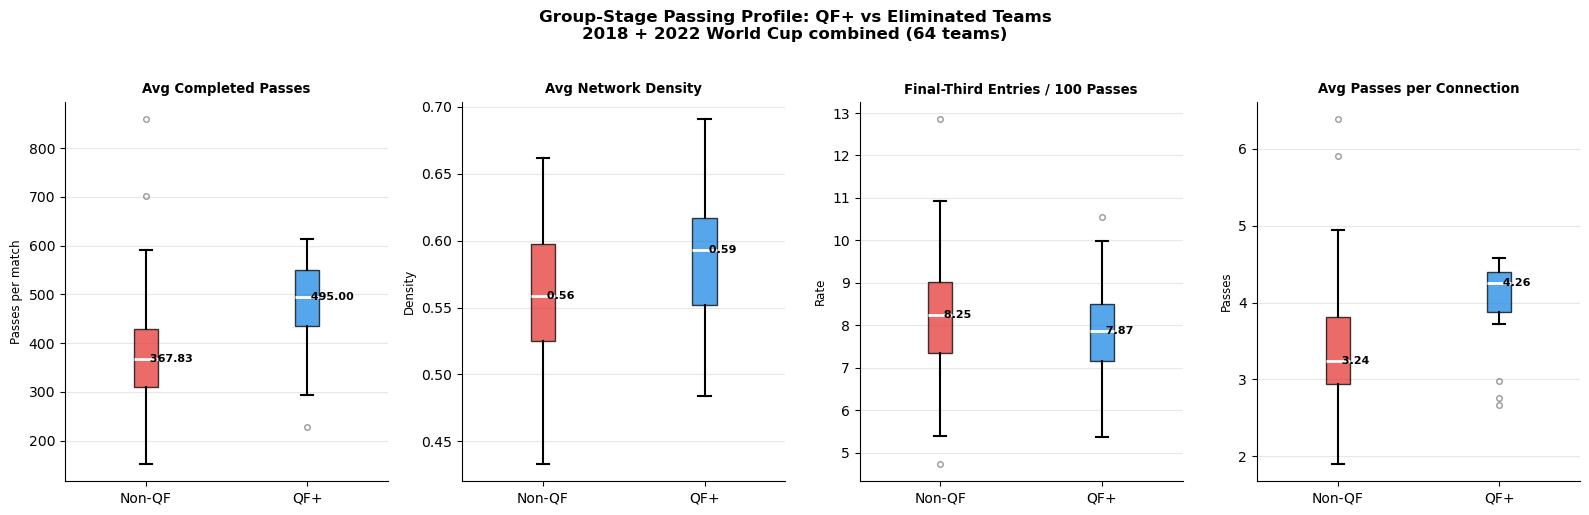

Saved: outputs/figures/06_combined_tournament_boxplots.png


In [10]:
QF_COLOR  = '#1E88E5'
ELM_COLOR = '#E53935'
YEAR_COLORS = {2018: '#FB8C00', 2022: '#8E24AA'}  # orange / purple

# ── Figure 1: combined boxplots for 4 key metrics ─────────────────────────
metrics_to_plot = [
    ('avg_completed_passes',                'Avg Completed Passes',          'Passes per match'),
    ('avg_network_density',                 'Avg Network Density',           'Density'),
    ('avg_final_third_entries_per_100_passes', 'Final-Third Entries / 100 Passes', 'Rate'),
    ('avg_passes_per_connection',            'Avg Passes per Connection',    'Passes'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(
    'Group-Stage Passing Profile: QF+ vs Eliminated Teams\n'
    '2018 + 2022 World Cup combined (64 teams)',
    fontsize=12, fontweight='bold', y=1.02,
)

for ax, (col, title, ylabel) in zip(axes, metrics_to_plot):
    bp = ax.boxplot(
        [combined[combined['reached_qf']==0][col].dropna(),
         combined[combined['reached_qf']==1][col].dropna()],
        labels=['Non-QF', 'QF+'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], [ELM_COLOR, QF_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for i, grp in enumerate([combined[combined['reached_qf']==0],
                              combined[combined['reached_qf']==1]]):
        med = grp[col].median()
        ax.text(i+1, med, f' {med:.2f}', va='center', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8.5)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_combined_tournament_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/06_combined_tournament_boxplots.png')

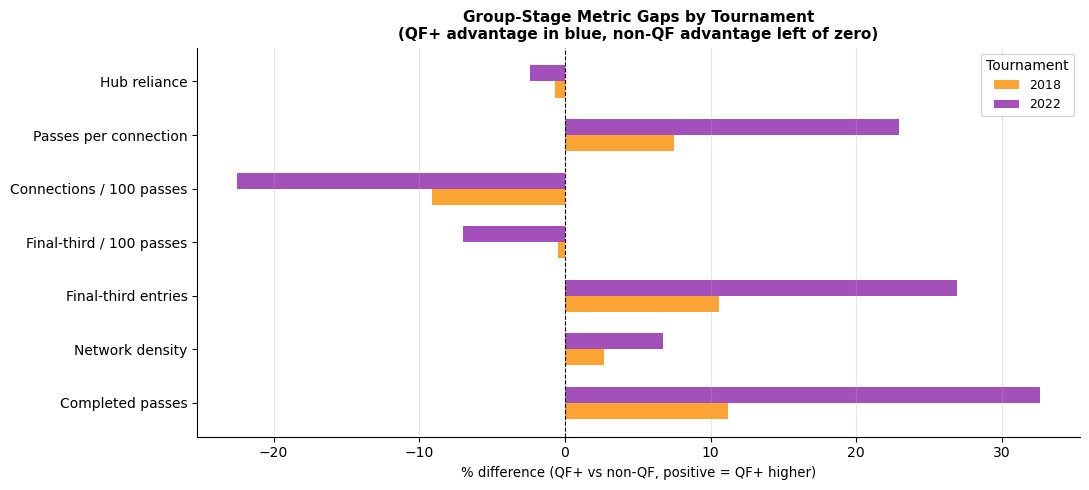

Saved: outputs/figures/06_metric_gap_by_tournament.png


In [11]:
# ── Figure 2: % gap between QF+ and non-QF, shown by tournament ───────────
metric_labels = {
    'avg_completed_passes':                   'Completed passes',
    'avg_network_density':                    'Network density',
    'avg_final_third_entries':                'Final-third entries',
    'avg_final_third_entries_per_100_passes': 'Final-third / 100 passes',
    'avg_connections_per_100_passes':         'Connections / 100 passes',
    'avg_passes_per_connection':              'Passes per connection',
    'avg_top_player_reliance':                'Hub reliance',
}

fig, ax = plt.subplots(figsize=(11, 5))
y_pos  = np.arange(len(COMPARE_COLS))
bar_h  = 0.3

for offset, (year, color) in enumerate([(2018, YEAR_COLORS[2018]),
                                         (2022, YEAR_COLORS[2022])]):
    sub = by_tournament[by_tournament['tournament_year'] == year]
    vals = [sub[sub['metric'] == c]['mean_diff_pct'].values[0] for c in COMPARE_COLS]
    ax.barh(y_pos + offset * bar_h, vals, height=bar_h,
            color=color, alpha=0.8, label=str(year))

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos + bar_h / 2)
ax.set_yticklabels([metric_labels[c] for c in COMPARE_COLS], fontsize=10)
ax.set_xlabel('% difference (QF+ vs non-QF, positive = QF+ higher)', fontsize=9.5)
ax.set_title('Group-Stage Metric Gaps by Tournament\n(QF+ advantage in blue, non-QF advantage left of zero)',
             fontsize=11, fontweight='bold')
ax.legend(title='Tournament', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_metric_gap_by_tournament.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/06_metric_gap_by_tournament.png')

## Key findings

### Cross-tournament consistency

The group-stage passing-network profile that separated QF+ teams in 2022 holds across both tournaments:

| Pattern | 2018 | 2022 |
|---|---|---|
| QF+ teams completed more passes | ✓ | ✓ |
| QF+ teams had denser networks | ✓ | ✓ |
| QF+ teams had lower final-third entries per 100 passes | ✓ | ✓ |
| QF+ teams had higher passes per connection | ✓ | ✓ |

The direction of every metric is consistent between 2018 and 2022. This is encouraging: it suggests the signals are not specific to a single tournament.

### What makes a QF team's passing profile distinctive?

Across both tournaments, QF+ teams show:
- **Higher volume** — more completed passes per group-stage match
- **Denser networks** — more of the possible player-to-player links were actually used
- **Repeated connections** — higher passes per unique connection (same pairs used more often)
- **Not more efficient per pass** — lower final-third rate, suggesting volume was the driver

This points to a **possession-based, structurally stable passing style**, not a direct or counterattacking one.

> **Next step:** Use these team profiles to train a logistic regression model on 2018 data and test it on 2022 data — see `notebooks/07_historical_qf_modeling.ipynb`.